# Were the HF END consensus alleles already present at PRE?

Two species carry only a handful of sites significant in **both** the HF-LF
divergence test and HF parallelism (q < 0.05): `SLG1171_DASTool_bins_9`
(*Odoribacter* sp910578105, 2 sites) and `SLG421_DASTool_bins_82`
(*Cryptobacteroides* sp009774765, 3 sites). Neither showed strain turnover in most
HF replicates, so those sites were proposed as **de novo mutations favoured by the
high-fat diet**.

**What this notebook does.** Each mouse calls its own major allele at a site (the
base with the most reads). Those per-sample calls are combined into a consensus
within each group x timepoint. Then, per site, we compare **HF PRE vs HF END** and
**LF PRE vs LF END** — did that arm's consensus change, and if so, was the END
allele already present in that arm at PRE, in how many mice, at what depth.

**Source is `profiles/`** — the only cheap table that is per-sample *and* per-site
*and* keeps monomorphic positions. That last property separates "absent at PRE"
from "never reported at PRE"; on a variant-only table you can manufacture a de novo
mutation out of a filtering artifact.

**Two caveats for every number below.** `total_coverage` is post-filter
deduplicated depth (MQ > 20, BQ >= 30, `ignore_orphans`, `ignore_overlaps`) and
sits **below physical read depth** — never quote it as raw read depth. A positive
detection is safe; a claimed *absence* is not, and would need the BAMs under
`/scratch/gpfs/AMOELLER/diet_manip/copy_sg4230_scratch/`.

Schemas and footguns: `alleleflux-internals` skill, `references/pipeline-and-stats.md` § 7.

In [1]:
# Environment: module load anaconda3/2025.12 && conda activate alleleflux
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# force=True: notebook cells get re-run, and without it each re-run stacks another
# handler on the root logger so every message prints N times.
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S", stream=sys.stderr, force=True)
logger = logging.getLogger("denovo_check")

# THE landmine of this project: several AlleleFlux trees hold identically named
# files with DIFFERENT contents. Pin the root in one variable, never glob.
# Published Fig 1 = AlleleFlux_mapq20, 62 paired pre_end MAGs.
RUN = Path("/scratch/gpfs/AMOELLER/diet_manip/AlleleFlux_mapq20/longitudinal")
COMPARISON = "pre_end-fat_control"          # directory name, "<timepoints>-<groups>"
PERIOD = COMPARISON.split("-", 1)[0]        # "pre_end" -- the p_value_summary filename infix
OUTDIR = Path("/scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/denovo_check")

# Matched against the `test_type` COLUMN: one file stacks rows from several tests.
DIVERGENCE_TEST = "two_sample_paired_tTest"   # between-group: did HF diverge from LF?
PARALLELISM_TEST = "single_sample_tTest"      # within-group: did HF mice move in parallel?
# BH-corrected q, pooled GENOME-WIDE across all MAGs -- so "q < 0.05 here" means
# significant in a global ranking, not within this species.
Q_THRESHOLD = 0.05

# Asserted against the metadata below rather than trusted. HF=fat/LF=control is a
# project convention; there is no diet-composition column in the metadata.
HF_GROUP, LF_GROUP = "fat", "control"
BASELINE_TIME, FOCUS_TIME = "pre", "end"
ARMS = {"HF": HF_GROUP, "LF": LF_GROUP}       # label -> metadata group value

MAGS = {"SLG1171_DASTool_bins_9": "Odoribacter sp910578105",
        "SLG421_DASTool_bins_82": "Cryptobacteroides sp009774765"}

# Nucleotide COUNT columns. Always index by name, never by position: the wider
# allele_analysis tables order their *_frequency columns A,T,G,C while the count
# columns are A,C,G,T, so positional access silently swaps G and T.
NUCS = ["A", "C", "G", "T"]
# Site identity. All three parts are needed -- position alone repeats across
# contigs, and contig+position repeats across MAGs.
KEY = ["mag_id", "contig", "position"]
CHUNK = 1_000_000                              # row chunk for the big streamed reads
# Ties in the vote are broken at RANDOM, not by label order -- alphabetical breaking
# would systematically favour A over T. Seeded so a run is reproducible; the RNG is
# re-seeded immediately before the groupby so re-running that cell alone repeats.
# The value is arbitrary (it is the date this analysis was pinned) -- any
# non-negative integer works and none is "more random" than another, since numpy
# hashes it through SeedSequence. It is recorded, not tuned: changing it would give
# a different but equally valid set of coin-flips. At these 5 sites it changes
# nothing at all, because no consensus here depends on a tie-break.
RNG_SEED = 20260825

OUTDIR.mkdir(parents=True, exist_ok=True)

## 1. Recover the target sites

`div_and_hf_sites_in_both.py` builds this join but aggregates the coordinates away,
so they are re-derived here and written out. A site qualifies only if the *same*
`(mag_id, contig, position)` clears q < 0.05 in both tests.

In [2]:
def load_significant(path, test_type, group):
    """Significant sites for one test, restricted to MAGS.

    Pinning test_type AND group_analyzed is what makes a row a site; uniqueness is
    asserted, not imposed -- a dedupe would silently merge the two diet groups if
    the group filter were ever dropped. These files are ~400 MB: chunked read with
    explicit usecols/dtype, never a default full read.
    """
    # Only the single_sample file has group_analyzed; asking for it on the
    # two_sample file is a hard read error, so request it conditionally.
    usecols = KEY + ["test_type", "q_value"] + (["group_analyzed"] if group else [])
    dtype = {"mag_id": "string", "contig": "string", "position": "int64",
             "test_type": "string", "q_value": "float64", "group_analyzed": "string"}

    keep = []
    for chunk in pd.read_csv(path, sep="\t", usecols=usecols,
                             # dtype is subset to the columns actually requested;
                             # pandas raises on a dtype key it is not reading.
                             dtype={k: v for k, v in dtype.items() if k in usecols},
                             chunksize=CHUNK):
        # Both pins are required for a row to mean "this site, this test": one file
        # stacks several tests, and single_sample stacks both diet groups too.
        sel = chunk["test_type"].eq(test_type) & chunk["mag_id"].isin(MAGS)
        if group:
            sel &= chunk["group_analyzed"].eq(group)
        if sel.any():
            keep.append(chunk.loc[sel, KEY + ["q_value"]])

    # Empty-safe concat: a MAG genuinely absent from a stratum yields no chunks.
    tested = pd.concat(keep, ignore_index=True) if keep else pd.DataFrame(columns=KEY + ["q_value"])
    # Assert one row per site rather than dedupe -- a dedupe would paper over a
    # broken filter instead of failing, e.g. merging HF and LF rows into one.
    if len(tested) != len(tested.drop_duplicates(KEY)):
        raise RuntimeError(f"{path.name}: duplicate rows on {KEY} -- filters no longer pin one row per site")

    # Cut on q AFTER the uniqueness check, so that check covers every tested row.
    sig = tested[tested.q_value < Q_THRESHOLD].reset_index(drop=True)
    logger.info(f"{path.name} [{test_type}{'/' + group if group else ''}]: "
                f"{len(sig):,} significant of {len(tested):,} tested")
    return sig


pv = RUN / "p_value_summary" / COMPARISON
# INNER join on the full site key: a position survives only if the SAME
# (mag, contig, position) cleared q < 0.05 in BOTH tests.
sites = (
    load_significant(pv / f"p_value_summary_two_sample_paired_{PERIOD}.tsv", DIVERGENCE_TEST, None)
    .merge(load_significant(pv / f"p_value_summary_single_sample_{PERIOD}.tsv", PARALLELISM_TEST, HF_GROUP),
           on=KEY, how="inner", suffixes=("_div", "_hf"))
    .sort_values(KEY).reset_index(drop=True)
)
sites["species"] = sites.mag_id.map(MAGS)
# An empty result means a wrong run root or a renamed test, not "no significant
# sites" -- we already know these two MAGs have some.
if sites.empty:
    raise RuntimeError("no doubly-significant sites -- check the run root and test names")

sites.to_csv(OUTDIR / "target_sites.tsv", sep="\t", index=False)
logger.info(f"{len(sites)} doubly-significant sites")
sites

14:14:51 [INFO] p_value_summary_two_sample_paired_pre_end.tsv [two_sample_paired_tTest]: 15 significant of 1,377 tested
14:14:54 [INFO] p_value_summary_single_sample_pre_end.tsv [single_sample_tTest/fat]: 90 significant of 1,127 tested
14:14:54 [INFO] 5 doubly-significant sites


,mag_id,contig,position,q_value_div,q_value_hf,species
0,SLG1171_DASTool_bins_9,SLG1171_DASTool_bins_9.fa_k141_184355,597,0.024980,0.015699,Odoribacter sp910578105
1,SLG1171_DASTool_bins_9,SLG1171_DASTool_bins_9.fa_k141_216652,14297,0.033045,0.039952,Odoribacter sp910578105
2,SLG421_DASTool_bins_82,SLG421_DASTool_bins_82.fa_k141_225286,1140,0.045761,0.031176,Cryptobacteroides sp009774765
3,SLG421_DASTool_bins_82,SLG421_DASTool_bins_82.fa_k141_65775,2563,0.024980,0.015713,Cryptobacteroides sp009774765
4,SLG421_DASTool_bins_82,SLG421_DASTool_bins_82.fa_k141_67511,179,0.028186,0.043243,Cryptobacteroides sp009774765


## 2. Pull the raw pileup rows, driven by the sample roster

The roster comes from the per-MAG metadata, **not** from whatever rows appear in
the profiles: a sample with zero high-quality coverage at a site has no row, and an
inner join would drop it and inflate the denominators. It fires — several samples
are missing at two sites. `file_path` is the exact profile path (sample ids contain
underscores, so never split `<SAMPLE>_<MAG>` on `_`).

~3 minutes: 120 gzipped profiles of ~2.8M rows each, a few positions wanted from each.

In [3]:
# Profile schema is 11 columns; we skip `mapq_scores` (a comma-separated STRING of
# one MAPQ per read) and `gene_id` (trailing space, empty at intergenic positions).
PROFILE_COLS = ["contig", "position", "ref_base", "total_coverage", *NUCS, "N"]
PROFILE_DTYPE = {"contig": "string", "position": "int64", "ref_base": "string",
                 "total_coverage": "int64", "N": "int64", **{n: "int64" for n in NUCS}}

# --- roster: one metadata sheet per MAG, 60 rows each (15 mice x 2 arms x 2 times)
roster = []
for mag_id in MAGS:
    path = RUN / "inputMetadata" / f"inputMetadata_{COMPARISON}" / f"{mag_id}_metadata.tsv"
    # dtype="string" throughout: every column is an identifier, and inference would
    # turn subjectID/replicate into ints and break the joins.
    roster.append(pd.read_csv(path, sep="\t", dtype="string").assign(mag_id=mag_id))
roster = pd.concat(roster, ignore_index=True)

# Read the vocabulary back out of the data instead of trusting the constants.
assert set(ARMS.values()) <= set(roster.group), f"group labels not in metadata: {set(roster.group)}"
assert {BASELINE_TIME, FOCUS_TIME} <= set(roster.time), f"time labels not in metadata: {set(roster.time)}"
print(roster.groupby(["mag_id", "time", "group"]).size().rename("n_samples").to_frame())

# --- scan: each profile is ~2.8M rows and we want <5, so stream and discard
hits = []
for mag_id in MAGS:
    want = sites.loc[sites.mag_id == mag_id]
    wanted = set(zip(want.contig, want.position))   # exact (contig, position) pairs
    contigs = set(want.contig)                      # coarser key for the prefilter
    mag_roster = roster[roster.mag_id == mag_id]
    logger.info(f"{mag_id}: scanning {len(mag_roster)} profiles for {len(wanted)} sites")

    for row in mag_roster.itertuples(index=False):
        fp = Path(row.file_path)
        if not fp.exists():
            logger.warning(f"profile missing, skipping: {fp}")
            continue
        for chunk in pd.read_csv(fp, sep="\t", usecols=PROFILE_COLS,
                                 dtype=PROFILE_DTYPE, chunksize=CHUNK):
            # Vectorised contig prefilter throws away nearly every row cheaply, so
            # the slow per-row pair test only sees a handful.
            sub = chunk[chunk.contig.isin(contigs)]
            if sub.empty:
                continue
            # position is 0-based and shares one namespace with p_value_summary,
            # so cell-3 coordinates are used with no translation.
            sub = sub[[p in wanted for p in zip(sub.contig, sub.position)]]
            if not sub.empty:
                hits.append(sub.assign(mag_id=mag_id, sample_id=row.sample_id))

observed = pd.concat(hits, ignore_index=True)

# --- zero-fill: make "no coverage" an explicit row -------------------------
# Cross every sample of a MAG with every site of that MAG (merging on mag_id alone
# is deliberate), THEN left-join the observed rows.
tidy = (roster.merge(sites[KEY + ["species"]], on="mag_id")
              .merge(observed, on=KEY + ["sample_id"], how="left"))
# `covered` must be captured BEFORE the fillna, or a genuine zero-coverage row
# becomes indistinguishable from one where the allele was truly seen 0 times.
tidy["covered"] = tidy.total_coverage.notna()
tidy[[*NUCS, "N", "total_coverage"]] = tidy[[*NUCS, "N", "total_coverage"]].fillna(0).astype("int64")

bad = tidy[tidy.covered & (tidy[[*NUCS, "N"]].sum(axis=1) != tidy.total_coverage)]
logger.info("A+C+G+T+N == total_coverage on every covered row" if bad.empty
            else f"WARNING: {len(bad)} rows where counts != total_coverage")
logger.info(f"{(~tidy.covered).sum()} of {len(tidy)} sample-site pairs have NO high-quality coverage")

tidy.to_csv(OUTDIR / "per_sample_site_counts.tsv", sep="\t", index=False)

14:14:54 [INFO] SLG1171_DASTool_bins_9: scanning 60 profiles for 2 sites


                                     n_samples
mag_id                 time group             
SLG1171_DASTool_bins_9 end  control         15
                            fat             15
                       pre  control         15
                            fat             15
SLG421_DASTool_bins_82 end  control         15
                            fat             15
                       pre  control         15
                            fat             15


14:17:43 [INFO] SLG421_DASTool_bins_82: scanning 60 profiles for 3 sites
14:19:45 [INFO] A+C+G+T+N == total_coverage on every covered row
14:19:45 [INFO] 7 of 300 sample-site pairs have NO high-quality coverage


## 3. The comparison: HF PRE vs HF END, LF PRE vs LF END

### How the consensus is taken — worked example

Real data, `k141_184355:597` (reference base G), the **HF END** stratum — all 15 HF
mice at the END timepoint. Counts are reads of each base in that mouse:

| mouse | A | C | G | T | this mouse's call |
|---|---|---|---|---|---|
| SLG530 | 15 | 0 | 8 | 0 | A |
| SLG992 | 11 | 0 | 6 | 0 | A |
| SLG1104 | 10 | 0 | 10 | 0 | A *(tie!)* |
| SLG1105 | 4 | 0 | 2 | 0 | A |
| SLG1122 | 25 | 0 | 15 | 0 | A |
| SLG1123 | 10 | 0 | 14 | 0 | G |
| SLG1133 | 14 | 0 | 8 | 0 | A |
| SLG1156 | 18 | 0 | 6 | 0 | A |
| SLG1157 | 6 | 0 | 1 | 0 | A |
| SLG1171 | 17 | 0 | 20 | 0 | G |
| SLG1173 | 6 | 0 | 7 | 0 | G |
| SLG1207 | 5 | 0 | 0 | 0 | A |
| SLG1208 | 2 | 0 | 8 | 0 | G |
| SLG1215 | 40 | 0 | 45 | 0 | G |
| SLG1216 | 12 | 0 | 8 | 0 | A |

**Step 1 — every sample calls its own base.** Each mouse takes the argmax over its
own A/C/G/T counts. SLG530 is 15 A vs 8 G, so it calls **A**; SLG1171 is 17 A vs
20 G, so it calls **G**.

**Step 2 — combine the calls within this group x timepoint.** A: 10 votes, G: 5.

**Step 3 — majority wins.** `hf_end_consensus = "A"`, `hf_end_vote_tally = "A:10 G:5"`.

**Every mouse counts once, regardless of sequencing depth** — that is the point of
voting rather than summing reads: SLG1215 contributes 85 reads and SLG1207 just 5,
but each casts one vote.

The same three steps run independently in all four strata: `hf_pre`, `hf_end`,
`lf_pre`, `lf_end`.

*Tie note:* SLG1104 is a genuine tie (A = 10, G = 10) and still casts a full vote.
Such ties are broken **at random** (seeded, `RNG_SEED`), not alphabetically —
breaking by label order would systematically favour A over T.
`n_<s>_tied_samples` counts these voters so a consensus resting on them is visible;
3 of the 5 sites have at least one. Brute-force enumeration over every possible
assignment of the tied voters (2026-08-25) shows no stratum consensus at these 5
sites can change, so the policy does not move any result here.

### Columns

Per stratum (`hf_pre`, `hf_end`, `lf_pre`, `lf_end`), all computed on that stratum alone:

| column | meaning |
|---|---|
| `<s>_consensus` | that stratum's consensus, by the per-sample vote above |
| `<s>_vote_tally` | the votes behind it, e.g. `"A:10 G:5"` |
| `n_<s>_samples` | mice with coverage here (i.e. voters) |
| `n_<s>_tied_samples` | voters whose own top two bases were level |
| `<s>_total_depth` | **every** read at this position here, whatever base it carries |
| `<s>_reads_supporting` | reads carrying `<s>_consensus` |
| `<s>_pct_supporting` | `reads_supporting / total_depth x 100` |
| `n_<s>_samples_with_allele` | mice carrying `<s>_consensus` on >= 1 read |

Then per arm, the **within-arm PRE -> END comparison**:

| column | meaning |
|---|---|
| `<arm>_consensus_same` | did that arm's consensus stay the same from PRE to END |
| `<arm>_pre_reads_end_allele` | reads at PRE, in that arm, carrying that arm's **END** consensus |
| `n_<arm>_pre_mice_with_end_allele` | mice at PRE, in that arm, carrying it on >= 1 read |
| `<arm>_pre_pct_end_allele` | that as a fraction of the arm's PRE depth |

The last three are the reviewer's question: if an arm's consensus changed, was the
new allele already there at baseline in that same arm, and how well covered was the
position.

In [4]:
def sample_vote(rows):
    """Per-sample calls combined into one consensus for this stratum.

    ONE VOTE PER SAMPLE: each mouse calls its own most-common base, and those calls
    are combined into a straight majority. Every mouse counts once regardless of
    sequencing depth -- without that, one deeply sequenced animal can outweigh
    several shallow ones.

    Ties are broken at RANDOM (seeded `rng`), both for a mouse's own call and for
    the majority itself. `idxmax`-style alphabetical breaking would systematically
    favour A over T, which is a real bias when a mouse sits at A=10, G=10.
    Verified 2026-08-25 by brute-force enumeration over every possible assignment
    of tied voters: at all 5 sites no stratum's consensus can change, so the
    tie-break policy does not move any result here -- but it could elsewhere.

    Returns (consensus, tally string, n samples whose own top base was tied).
    """
    if not len(rows):
        return None, "", 0

    counts = rows[NUCS].to_numpy(copy=True)      # copy=True: we must not touch `tidy`
    top = counts.max(axis=1, keepdims=True)
    is_top = counts == top                       # True at every base tied for the max
    n_tied = int((is_top.sum(axis=1) > 1).sum()) # mice with >1 base at their maximum

    # Random pick among the tied maxima: score each candidate with a uniform draw and
    # take the largest. Non-candidates get -1 so they can never win. A row that is all
    # zeros (pure-N coverage) has every base "tied" and picks uniformly among four.
    pick = np.where(is_top, rng.random(counts.shape), -1.0).argmax(axis=1)
    tally = pd.Series([NUCS[i] for i in pick]).value_counts()

    # Majority, with the same random policy if two bases draw the same vote count.
    leaders = tally.index[tally == tally.max()].to_numpy()
    consensus = leaders[0] if len(leaders) == 1 else str(rng.choice(leaders))
    return consensus, " ".join(f"{b}:{n}" for b, n in tally.items()), n_tied


def stratum_stats(rows, prefix):
    """One stratum's own consensus and how solidly its reads back it.

    total_depth is EVERY read at the position here, whatever base it carries -- the
    denominator. reads_supporting is only the reads carrying this stratum's own
    consensus -- the numerator. Their difference is reads carrying some other base.
    """
    consensus, tally, n_tied = sample_vote(rows)
    depth = int(rows.total_coverage.sum())
    supporting = int(rows[consensus].sum()) if consensus else 0
    return {
        f"{prefix}_consensus": consensus,
        f"{prefix}_vote_tally": tally,
        f"n_{prefix}_samples": len(rows),
        f"n_{prefix}_tied_samples": n_tied,
        f"{prefix}_total_depth": depth,
        f"{prefix}_reads_supporting": supporting,
        f"{prefix}_pct_supporting": round(100 * supporting / depth, 1) if depth else float("nan"),
        # Breadth as well as depth: 60 reads in one mouse is a weaker claim than
        # 3 reads in each of 20 mice.
        f"n_{prefix}_samples_with_allele": int((rows[consensus] > 0).sum()) if consensus else 0,
    }


def summarise(sub):
    """One answer row per site: four strata, then the two within-arm comparisons."""
    # Only covered rows take part -- a zero-filled row means "not observed", and
    # counting it would drag every consensus toward whatever allele is scarcest.
    # The assembly reference base. NOT a consensus, and empirically often not even
    # the most common base; here only so a site reads as "G -> A". It is a property
    # of the assembly, so every covered sample must report the SAME base -- a
    # disagreement means the rows are not all the same locus (a bad join, or a
    # contig name collision), which must fail loudly rather than be averaged away.
    ref_bases = set(sub.loc[sub.covered, "ref_base"].dropna())
    if len(ref_bases) > 1:
        raise ValueError(f"ref_base disagrees across samples at one site: {sorted(ref_bases)}")

    out = {"species": sub.species.iat[0],
           "ref_base": next(iter(ref_bases)) if ref_bases else None}

    # Four strata = arm x timepoint. Each is sliced independently and never pooled
    # with another: the arms can already differ at PRE (at k141_65775:2563 the HF
    # mice's baseline consensus is C while the LF mice's is T), and pooling hides that.
    # The row slices are kept because the comparison below needs the PRE rows again.
    # The timepoint value doubles as the column-name component, so "hf" + "pre"
    # gives the hf_pre_* columns. Downstream code refers to those names literally;
    # the assert in the roster cell is what guarantees the constants really are
    # "pre" and "end", so the two stay in step.
    arm_rows = {}
    for label, group in ARMS.items():
        arm = label.lower()
        for tp in (BASELINE_TIME, FOCUS_TIME):
            rows = sub[(sub.group == group) & (sub.time == tp) & sub.covered]
            arm_rows[f"{arm}_{tp}"] = rows
            out.update(stratum_stats(rows, f"{arm}_{tp}"))

    # --- the comparison: within each arm, PRE vs END -----------------------
    for label in ARMS:
        arm = label.lower()
        pre_rows = arm_rows[f"{arm}_pre"]
        pre_cons = out[f"{arm}_pre_consensus"]
        end_cons = out[f"{arm}_end_consensus"]
        # Same animals' lineage, so a change here is a real turnover in that arm.
        out[f"{arm}_consensus_same"] = pre_cons == end_cons
        # Was that arm's END allele already present in that arm at PRE? ">0" is
        # deliberate -- the question was "at any frequency, even a single read".
        reads = int(pre_rows[end_cons].sum()) if end_cons and len(pre_rows) else 0
        depth = out[f"{arm}_pre_total_depth"]
        out[f"{arm}_pre_reads_end_allele"] = reads
        out[f"{arm}_pre_pct_end_allele"] = round(100 * reads / depth, 1) if depth else float("nan")
        out[f"n_{arm}_pre_mice_with_end_allele"] = (
            int((pre_rows[end_cons] > 0).sum()) if end_cons and len(pre_rows) else 0)
        out[f"{arm}_end_allele_present_at_pre"] = reads > 0

    return pd.Series(out)


# Re-seeded here, not in the setup cell, so re-running THIS cell alone reproduces
# the same tie-breaks. sort=True fixes the group order, which the RNG stream follows.
rng = np.random.default_rng(RNG_SEED)
# include_groups=False keeps the KEY columns out of `sub` (pandas >= 2.2);
# reset_index puts them back as real columns afterwards.
answers = tidy.groupby(KEY, sort=True).apply(summarise, include_groups=False).reset_index()
answers.to_csv(OUTDIR / "pre_presence_summary.tsv", sep="\t", index=False)

# =====================  THE ANSWER TABLE  =====================
# Two rows per site, one per diet arm: did that arm's consensus change from PRE to
# END, and if so was the END allele already present in that arm at PRE.
def _arm_answer(label):
    """The answer rows for one diet arm, readable columns first."""
    a = label.lower()
    pre_c, end_c = answers[f"{a}_pre_consensus"], answers[f"{a}_end_consensus"]
    same = answers[f"{a}_consensus_same"]
    reads, depth = answers[f"{a}_pre_reads_end_allele"], answers[f"{a}_pre_total_depth"]
    pct = answers[f"{a}_pre_pct_end_allele"]
    n_with, n_tot = answers[f"n_{a}_pre_mice_with_end_allele"], answers[f"n_{a}_pre_samples"]

    # "G -> A", or "unchanged" where the arm's consensus never moved.
    change = (pre_c.astype(str) + " -> " + end_c.astype(str)).where(~same, "unchanged")
    # "27/192 reads (14.1%), 9/15 mice" -- the END allele's PRE support in one cell.
    # Blank where nothing changed: there is no new allele to have been present.
    at_pre = (reads.astype(str) + "/" + depth.astype(str) + " reads ("
              + pct.astype(str) + "%), " + n_with.astype(str) + "/" + n_tot.astype(str)
              + " mice").where(~same, "")

    return pd.DataFrame({
        "contig": answers.contig.str.split(".fa_").str[-1],
        "position": answers.position,
        "ref": answers.ref_base,
        "arm": label,
        # --- the readable summary ---
        "pre_consensus": pre_c,
        "end_consensus": end_c,
        "changed": ~same,
        "change": change,
        "end_allele_present_at_pre": answers[f"{a}_end_allele_present_at_pre"].where(~same, pd.NA),
        "end_allele_at_pre": at_pre,
        # --- the same numbers, unformatted, for downstream use ---
        "pre_reads_end_allele": reads,
        "pre_total_depth": depth,
        "pre_pct_end_allele": pct,
        "n_pre_mice_with_end_allele": n_with,
        "n_pre_mice": n_tot,
    })


answer = (pd.concat([_arm_answer(label) for label in ARMS])
            .sort_values(["contig", "position", "arm"]).reset_index(drop=True))

answer.to_csv(OUTDIR / "answer_summary.tsv", sep="\t", index=False)
answer

,contig,position,ref,arm,pre_consensus,end_consensus,changed,change,end_allele_present_at_pre,end_allele_at_pre,pre_reads_end_allele,pre_total_depth,pre_pct_end_allele,n_pre_mice_with_end_allele,n_pre_mice
0,k141_184355,597,G,HF,G,A,True,G -> A,True,"27/192 reads (14.1%), 9/15 mice",27,192,14.1,9,15
1,k141_184355,597,G,LF,G,G,False,unchanged,<NA>,,215,250,86.0,15,15
2,k141_216652,14297,A,HF,A,A,False,unchanged,<NA>,,159,159,100.0,15,15
3,k141_216652,14297,A,LF,A,A,False,unchanged,<NA>,,233,238,97.9,15,15
4,k141_225286,1140,A,HF,G,G,False,unchanged,<NA>,,676,770,87.8,15,15
5,k141_225286,1140,A,LF,G,G,False,unchanged,<NA>,,1116,1217,91.7,15,15
6,k141_65775,2563,T,HF,C,T,True,C -> T,True,"86/181 reads (47.5%), 15/15 mice",86,181,47.5,15,15
7,k141_65775,2563,T,LF,T,T,False,unchanged,<NA>,,126,203,62.1,15,15
8,k141_67511,179,T,HF,T,C,True,T -> C,True,"35/124 reads (28.2%), 11/14 mice",35,124,28.2,11,14
9,k141_67511,179,T,LF,T,T,False,unchanged,<NA>,,77,117,65.8,15,15


## 4. The divergent allele, not the major allele

Section 3 assumed the allele showing divergence was the HF END major allele. That
is not guaranteed. The divergence test scores **each nucleotide separately**, and
`p_value_summary` keeps only `min_p_value` — the smallest of the four. So the allele
driving significance is whichever nucleotide produced that minimum, and it can be a
**minor** allele that never becomes the consensus. That is why two sites looked
"unchanged" in section 3.

This section identifies that allele at each site and asks the same de novo question
of it: **was it present at PRE?**

HF is the focus, but LF PRE is reported too, because it bears directly on the
answer: an allele undetected in HF at baseline but present in LF mice already
existed in the cohort, which argues for standing variation sitting below the HF
detection floor rather than a new mutation.

Two things to keep in mind:

- At a strictly **biallelic** site the two alleles get *identical* p-values, because
  freq_A = 1 − freq_G makes their per-mouse changes exact negatives and the paired
  t-test symmetric. Both are reported; neither is "the" significant one — the signal
  is the balance between them.
- **An absence needs care.** A zero means zero *high-quality* reads, and the
  detection floor is set by the depth in that row. Only the BAMs can separate
  "truly absent" from "present below the floor".

In [5]:
# The divergence test scores each nucleotide separately and p_value_summary keeps
# only the smallest of the four, so the identity of the significant allele is lost
# there. Recover it from the upstream per-nucleotide table.
# NUC_P is built from NUCS so the two lists stay positionally aligned -- the zip
# below relies on element i of one naming element i of the other.
NUC_P = [f"{n}_frequency_p_value_tTest" for n in NUCS]

# --- 1. which allele drove the divergence signal at each site? ---------------
frames = []
for mag_id in MAGS:
    f = (RUN / "significance_tests" / f"two_sample_paired_{COMPARISON}"
         / f"{mag_id}_two_sample_paired.tsv.gz")
    # usecols keeps this to 6 columns; the file covers the whole MAG.
    d = pd.read_csv(f, sep="\t", usecols=["contig", "position", *NUC_P])
    # Inner join to our 5 sites, and pick up mag_id from the sites table.
    frames.append(d.merge(sites.loc[sites.mag_id == mag_id, KEY], on=["contig", "position"]))
per_nuc = pd.concat(frames, ignore_index=True)

# Row-wise minimum over the four nucleotides == min_p_value in p_value_summary.
per_nuc["min_p"] = per_nuc[NUC_P].min(axis=1)

# One row per (site, divergent allele). getattr() is how a namedtuple from
# itertuples is indexed by a column name held in a variable. The tolerance rather
# than == guards the biallelic case: those two alleles are mathematically identical
# but computed independently, so a half-ULP difference would silently drop one of
# them and report a single winner where two tie.
div = pd.DataFrame([
    {"mag_id": r.mag_id, "contig": r.contig, "position": r.position,
     "allele": n, "min_p": r.min_p}
    for r in per_nuc.itertuples(index=False)
    for n, col in zip(NUCS, NUC_P) if abs(getattr(r, col) - r.min_p) < 1e-12
])

# --- 1b. GTDB lineage for these MAGs ----------------------------------------
# From the Fig-1 scores table -- the same file div_and_hf_sites_in_both.py uses as
# its species -> MAG map, so the labels here match the rest of the revision work.
# GTDB ranks, in lineage order. "class" is a Python keyword, so these columns are
# only ever reached by name (df["class"]), never by attribute or itertuples.
TAXA = ["phylum", "class", "order", "family", "genus", "species"]
taxonomy = pd.read_csv(
    RUN / "scores" / "processed" / "combined" / "MAG"
    / f"scores_two_sample_paired-{COMPARISON}-MAGs.tsv",
    sep="\t", usecols=["MAG_ID", *TAXA]).rename(columns={"MAG_ID": "mag_id"})

# --- 2. was that allele present at PRE? --------------------------------------
# Reuses `tidy` from section 2, so there is no second pass over the profiles.
out = []
for r in div.itertuples(index=False):
    # Covered rows only: a zero-filled row means "not sequenced here", which is not
    # the same as "allele seen zero times" and must not count toward the depth.
    site = tidy[(tidy.mag_id == r.mag_id) & (tidy.contig == r.contig)
                & (tidy.position == r.position) & tidy.covered]
    row = {"mag_id": r.mag_id,
           "contig": r.contig.split(".fa_")[-1],   # drop the "<MAG>.fa_" prefix
           "position": r.position, "allele": r.allele, "min_p": r.min_p}

    # Same five columns for every arm x timepoint, so PRE and END are directly
    # comparable. HF answers the question; LF is the cross-check that tells us
    # whether an allele missing from HF at PRE existed in the cohort at all.
    for label, group in ARMS.items():
        for tp in (BASELINE_TIME, FOCUS_TIME):
            a = f"{label.lower()}_{tp}"
            rows_ = site[(site.group == group) & (site.time == tp)]
            reads = int(rows_[r.allele].sum())      # reads carrying the divergent allele
            depth = int(rows_.total_coverage.sum()) # ALL reads here, whatever the base
            row[f"{a}_reads"] = reads
            row[f"{a}_depth"] = depth
            row[f"{a}_pct"] = round(100 * reads / depth, 1) if depth else float("nan")
            # Breadth as well as depth: 27 reads over 9 mice is a stronger claim
            # than 27 reads in a single animal.
            row[f"n_{a}_mice"] = int((rows_[r.allele] > 0).sum())
            row[f"n_{a}_total"] = len(rows_)

    # Three-way verdict. ">0" is the whole test: present at ANY frequency, even one
    # read. The middle case is the important one -- absent from HF but present in LF
    # means the variant was already segregating, just under the HF detection floor.
    if row["hf_pre_reads"]:
        verdict = "standing variation (present in HF at PRE)"
    elif row["lf_pre_reads"]:
        verdict = "below HF detection at PRE, but present in LF -- standing variation"
    else:
        verdict = "not detected at PRE in either arm -- check BAMs before calling de novo"
    row["verdict"] = verdict
    out.append(row)

divergent_answer = pd.DataFrame(out).merge(taxonomy, on="mag_id", how="left")
# A MAG with no lineage row would silently carry NaNs through into the table.
assert divergent_answer["species"].notna().all(), "a MAG is missing from the scores table"
# Identity first, then the per-stratum numbers.
front = ["mag_id", *TAXA, "contig", "position", "allele", "min_p"]
divergent_answer = divergent_answer[front + [c for c in divergent_answer.columns if c not in front]]

divergent_answer.to_csv(OUTDIR / "divergent_allele_summary.tsv", sep="\t", index=False)
divergent_answer

,mag_id,phylum,class,order,family,genus,species,contig,position,allele,...,lf_pre_depth,lf_pre_pct,n_lf_pre_mice,n_lf_pre_total,lf_end_reads,lf_end_depth,lf_end_pct,n_lf_end_mice,n_lf_end_total,verdict
0,SLG1171_DASTool_bins_9,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter sp910578105,k141_184355,597,A,...,250,14.0,13,15,82,229,35.8,12,15,standing variation (present in HF at PRE)
1,SLG1171_DASTool_bins_9,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter sp910578105,k141_184355,597,G,...,250,86.0,15,15,147,229,64.2,15,15,standing variation (present in HF at PRE)
2,SLG1171_DASTool_bins_9,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter sp910578105,k141_216652,14297,T,...,238,1.3,2,15,4,151,2.6,3,14,"below HF detection at PRE, but present in LF -..."
3,SLG421_DASTool_bins_82,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp009774765,k141_225286,1140,A,...,1217,8.3,13,15,97,838,11.6,13,15,standing variation (present in HF at PRE)
4,SLG421_DASTool_bins_82,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp009774765,k141_225286,1140,G,...,1217,91.7,15,15,741,838,88.4,15,15,standing variation (present in HF at PRE)
5,SLG421_DASTool_bins_82,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp009774765,k141_65775,2563,C,...,203,37.9,15,15,64,146,43.8,14,14,standing variation (present in HF at PRE)
6,SLG421_DASTool_bins_82,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp009774765,k141_65775,2563,T,...,203,62.1,15,15,82,146,56.2,14,14,standing variation (present in HF at PRE)
7,SLG421_DASTool_bins_82,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp009774765,k141_67511,179,T,...,117,65.8,15,15,57,87,65.5,12,15,standing variation (present in HF at PRE)


## 5. Eye test: allele-frequency trajectories per cage

The frequency changes behind some of these p-values are small, so this plots the
data the statistics were run on. One panel per (site, divergent allele) from
section 4; PRE → POST → END on the x-axis (TruSeq only). **Each thin line is one
cage** — the mean frequency of that cage's mice at each timepoint. The thick line
is the arm mean, which is what the divergence test compares between HF and LF.

Frequency per mouse is reads of the allele over total depth in that mouse, with no
depth floor — the same per-mouse values the t-test saw. A mouse at 1–2 reads is a
coin flip and can swing a cage line; that noise is part of what to look at. Mice
with no coverage at a timepoint are left out of their cage's mean, not counted as
zero. Biallelic sites appear as mirror-image pairs, since freq_A = 1 − freq_G.

POST is not in `tidy` (section 2 read the pre_end metadata), so this cell scans the
30 POST profiles for each MAG first — about 1.5 minutes.

15:01:29 [INFO] POST: 144 of 150 sample-site pairs covered


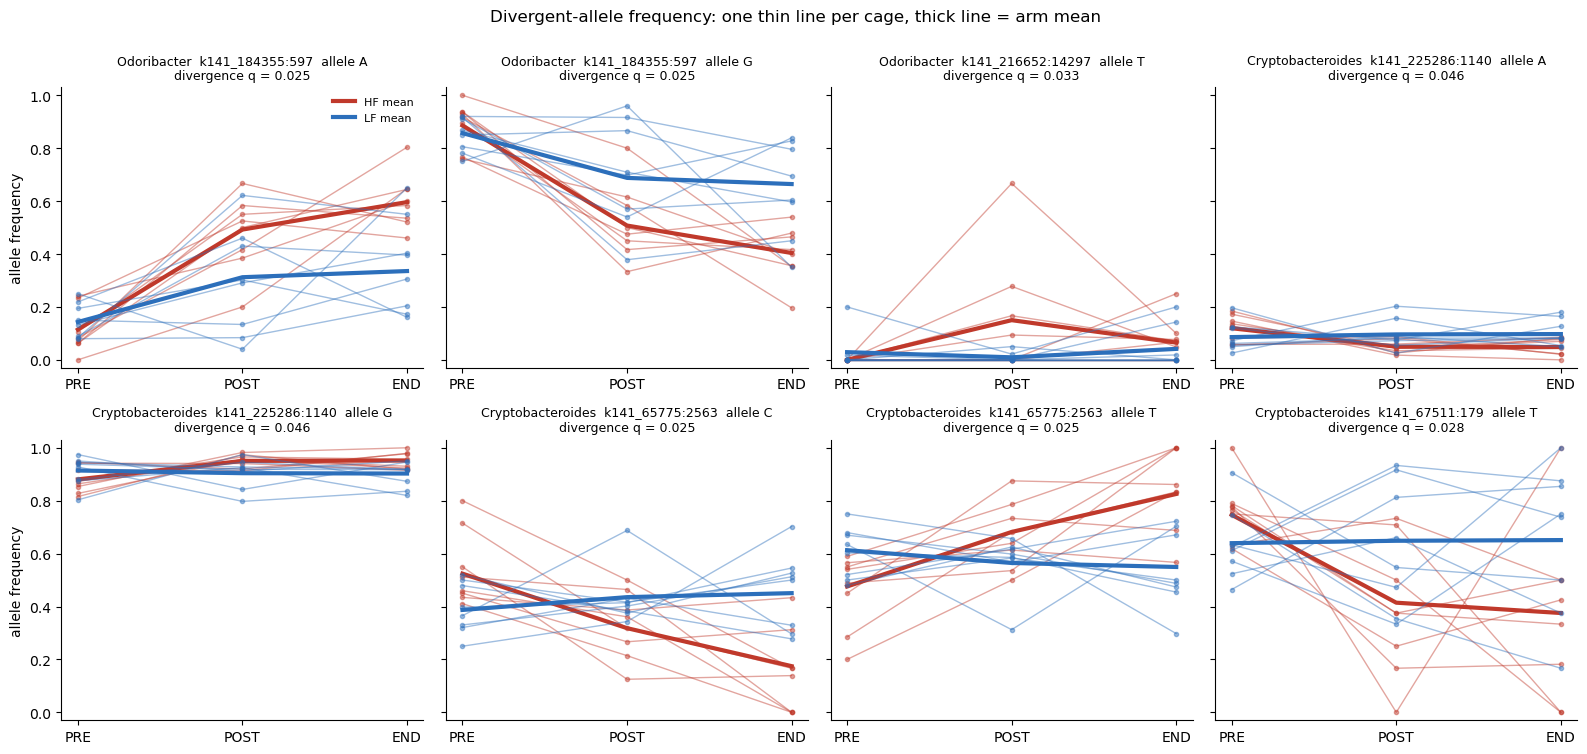

In [23]:
import matplotlib.pyplot as plt

# --- 1. add the POST samples --------------------------------------------------
# `tidy` (section 2) holds PRE and END only, because it was built from the
# pre_end metadata. POST lives in the pre_post metadata for the same 30 mice.
# Rather than rescan all 90 samples, scan just the 30 POST ones and append.
# TIMEPOINTS fixes the x-axis order; it is asserted against the data below.
TIMEPOINTS = ["pre", "post", "end"]

post_roster = pd.concat([
    pd.read_csv(RUN / "inputMetadata" / "inputMetadata_pre_post-fat_control"
                / f"{m}_metadata.tsv", sep="\t", dtype="string").assign(mag_id=m)
    for m in MAGS], ignore_index=True)
# The pre_post sheet also lists the PRE samples, which tidy already has -- keep
# only the samples tidy has never seen, and confirm those are all POST.
post_roster = post_roster[~post_roster.sample_id.isin(tidy.sample_id)]
assert set(post_roster.time) == {"post"}, set(post_roster.time)
assert set(TIMEPOINTS) == set(tidy.time) | set(post_roster.time)

# Same streaming scan as section 2: each profile is ~2.8M rows and we want <5.
hits = []
for mag_id in MAGS:
    want = sites.loc[sites.mag_id == mag_id]
    wanted, contigs = set(zip(want.contig, want.position)), set(want.contig)
    for row in post_roster[post_roster.mag_id == mag_id].itertuples(index=False):
        for chunk in pd.read_csv(row.file_path, sep="\t", usecols=PROFILE_COLS,
                                 dtype=PROFILE_DTYPE, chunksize=CHUNK):
            
            sub = chunk[chunk.contig.isin(contigs)]       # cheap prefilter first
            sub = sub[[p in wanted for p in zip(sub.contig, sub.position)]]
            if not sub.empty:
                hits.append(sub.assign(mag_id=mag_id, sample_id=row.sample_id))

# Same zero-fill as section 2: cross every POST sample with every site of its
# MAG, then left-join what was found, so "no coverage" is an explicit row.
post = (post_roster.merge(sites[KEY + ["species"]], on="mag_id")
                   .merge(pd.concat(hits, ignore_index=True), on=KEY + ["sample_id"], how="left"))
post["covered"] = post.total_coverage.notna()     # must precede the fillna
post[[*NUCS, "N", "total_coverage"]] = post[[*NUCS, "N", "total_coverage"]].fillna(0).astype("int64")
tidy3 = pd.concat([tidy, post], ignore_index=True)  # PRE + END + POST
logger.info(f"POST: {post.covered.sum()} of {len(post)} sample-site pairs covered")

# --- 2. one line per cage, one panel per (site, divergent allele) --------------
# Frequency per mouse = reads of the allele / total depth in that mouse. Only
# covered rows take part: a mouse with no reads here has no frequency, and
# treating it as 0 would drag its cage's line down for no biological reason.
# There is deliberately NO depth floor -- these are the same per-mouse values the
# t-test used. A mouse at 1-2 reads is a coin flip that can swing a cage line;
# that noise is part of what the eye test is meant to reveal.
cov = tidy3[tidy3.covered].copy()
cov["cage"] = cov.group + cov.replicate     # both arms reuse replicate numbers,
                                            # so "4" alone would merge two cages
q_div = sites.set_index(KEY).q_value_div    # divergence q, for the panel titles

COLORS = {"HF": "#c0392b", "LF": "#2c6fbb"} # validated colourblind-safe pair

# 2 x 4 grid = the 8 (site, allele) rows of divergent_answer; biallelic sites
# contribute two panels that are mirror images (freq_A = 1 - freq_G).
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharey=True)
for ax, r in zip(axes.flat, divergent_answer.itertuples(index=False)):
    # divergent_answer stores the contig SUFFIX; tidy has the full name.
    full_contig = f"{r.mag_id}.fa_{r.contig}"
    site = cov[(cov.mag_id == r.mag_id) & (cov.contig == full_contig)
               & (cov.position == r.position)].copy()
    site["freq"] = site[r.allele] / site.total_coverage

    for label, group in ARMS.items():
        arm = site[site.group == group]

        # Thin line per cage: mean of that cage's mice at each timepoint. unstack
        # turns the (cage, time) series into one row per cage; reindex forces the
        # column order to PRE/POST/END and leaves NaN where a cage had no
        # covered mouse, which matplotlib draws as a gap rather than a zero.
        cage_means = (arm.groupby(["cage", "time"]).freq.mean()
                         .unstack("time").reindex(columns=TIMEPOINTS))
        for _, ys in cage_means.iterrows():
            ax.plot(range(len(TIMEPOINTS)), ys.values, color=COLORS[label],
                    alpha=0.45, lw=1, marker="o", ms=3)

        # Thick line per arm: mean over all its mice -- the quantity the
        # divergence test actually compares between HF and LF.
        arm_mean = arm.groupby("time").freq.mean().reindex(TIMEPOINTS)
        ax.plot(range(len(TIMEPOINTS)), arm_mean.values, color=COLORS[label],
                lw=3, label=f"{label} mean")

    ax.set_title(f"{r.genus}  {r.contig}:{r.position}  allele {r.allele}\n"
                 f"divergence q = {q_div[(r.mag_id, full_contig, r.position)]:.3f}", fontsize=9)
    ax.set_xticks(range(len(TIMEPOINTS)))
    ax.set_xticklabels([t.upper() for t in TIMEPOINTS])
    # Shared 0-1 axis on purpose: a small effect should LOOK small. Autoscaling
    # would magnify the two flat panels, and magnify their noise with them.
    ax.set_ylim(-0.03, 1.03)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[:, 0]:                       # y-label on the left column only
    ax.set_ylabel("allele frequency")
axes[0, 0].legend(frameon=False, fontsize=8)  # one legend; colours are shared
fig.suptitle("Divergent-allele frequency: one thin line per cage, thick line = arm mean", y=1.0)
fig.tight_layout()
fig.savefig(OUTDIR / "divergent_allele_trajectories.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "divergent_allele_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()